In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import shap

%matplotlib inline

In [2]:
df_2020 = pd.read_csv('data/delta_table_2020_3x3.csv')
df_2021 = pd.read_csv('data/delta_table_2021_3x3.csv')

df_2021 = df_2021[df_2021['delta_years'] != 5]

In [3]:
df_2020 = df_2020.drop(columns=['year', "system:index", "image_count", ".geo", "geometry", "x", "y"])
df_2020 = df_2020.fillna(df_2020.mean())

df_2021 = df_2021.drop(columns=['year', "system:index", "image_count", ".geo", "geometry", "x", "y"])
df_2021 = df_2021.fillna(df_2021.mean())

In [4]:
df_2020['vegetation'] = df_2020[['tree_cover', 'cropland', 'grassland']].sum(axis=1)
df_2021['vegetation'] = df_2021[['tree_cover', 'cropland', 'grassland']].sum(axis=1)

target_labels = [
    'built_up',
    'vegetation',
    'water'
]

remaining_target = [
    'bare_sparse_vegetation',
    'tree_cover',
    'grassland',
    'cropland'
]


In [5]:
# --- Feature Engineering for df_2020 ---
# Vegetation Indices
df_2020['NDVI'] = (df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + df_2020['B4'] + 1e-8)
# df_2020['EVI'] = 2.5 * ((df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + 6 * df_2020['B4'] - 7.5 * df_2020['B2'] + 1 + 1e-8))
df_2020['EVI2'] = 2.5 * ((df_2020['B8'] - df_2020['B4']) / (df_2020['B8'] + 2.4 * df_2020['B4'] + 1 + 1e-8))
df_2020['SAVI'] = ((df_2020['B8'] - df_2020['B4']) * 1.5) / (df_2020['B8'] + df_2020['B4'] + 0.5 + 1e-8)
# df_2020['NDRE'] = (df_2020['B8'] - df_2020['B5']) / (df_2020['B8'] + df_2020['B5'] + 1e-8)
# df_2020['GNDVI'] = (df_2020['B8'] - df_2020['B3']) / (df_2020['B8'] + df_2020['B3'] + 1e-8)

# Urban & Built-up Indices
df_2020['NDBI'] = (df_2020['B11'] - df_2020['B8']) / (df_2020['B11'] + df_2020['B8'] + 1e-8)

# Water & Moisture Indices
df_2020['NDWI'] = (df_2020['B3'] - df_2020['B8']) / (df_2020['B3'] + df_2020['B8'] + 1e-8)
df_2020['MNDWI'] = (df_2020['B3'] - df_2020['B11']) / (df_2020['B3'] + df_2020['B11'] + 1e-8)


# --- Feature Engineering for df_2021 ---
# Vegetation Indices
df_2021['NDVI'] = (df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + df_2021['B4'] + 1e-8)
# df_2021['EVI'] = 2.5 * ((df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + 6 * df_2021['B4'] - 7.5 * df_2021['B2'] + 1 + 1e-8))
df_2021['EVI2'] = 2.5 * ((df_2021['B8'] - df_2021['B4']) / (df_2021['B8'] + 2.4 * df_2021['B4'] + 1 + 1e-8))
df_2021['SAVI'] = ((df_2021['B8'] - df_2021['B4']) * 1.5) / (df_2021['B8'] + df_2021['B4'] + 0.5 + 1e-8)
# df_2021['NDRE'] = (df_2021['B8'] - df_2021['B5']) / (df_2021['B8'] + df_2021['B5'] + 1e-8)
# df_2021['GNDVI'] = (df_2021['B8'] - df_2021['B3']) / (df_2021['B8'] + df_2021['B3'] + 1e-8)

# Urban & Built-up Indices
df_2021['NDBI'] = (df_2021['B11'] - df_2021['B8']) / (df_2021['B11'] + df_2021['B8'] + 1e-8)

# Water & Moisture Indices
df_2021['NDWI'] = (df_2021['B3'] - df_2021['B8']) / (df_2021['B3'] + df_2021['B8'] + 1e-8)
df_2021['MNDWI'] = (df_2021['B3'] - df_2021['B11']) / (df_2021['B3'] + df_2021['B11'] + 1e-8)

In [6]:
X_train = df_2020.drop(columns=target_labels + remaining_target)
X_train = X_train.drop(columns=['B4', 'B7', 'B8', 'NDBI'])
y_train = df_2020[target_labels]

X_test = df_2021.drop(columns=target_labels + remaining_target)
X_test = X_test.drop(columns=['B4', 'B7', 'B8', 'NDBI'])
y_test = df_2021[target_labels]

In [7]:
X_train.columns, y_train.columns

(Index(['delta_years', 'B11', 'B12', 'B2', 'B3', 'B5', 'B6', 'B11_m1_m1',
        'B12_m1_m1', 'B2_m1_m1', 'B3_m1_m1', 'B4_m1_m1', 'B5_m1_m1', 'B6_m1_m1',
        'B7_m1_m1', 'B8_m1_m1', 'B11_p0_m1', 'B12_p0_m1', 'B2_p0_m1',
        'B3_p0_m1', 'B4_p0_m1', 'B5_p0_m1', 'B6_p0_m1', 'B7_p0_m1', 'B8_p0_m1',
        'B11_p1_m1', 'B12_p1_m1', 'B2_p1_m1', 'B3_p1_m1', 'B4_p1_m1',
        'B5_p1_m1', 'B6_p1_m1', 'B7_p1_m1', 'B8_p1_m1', 'B11_m1_p0',
        'B12_m1_p0', 'B2_m1_p0', 'B3_m1_p0', 'B4_m1_p0', 'B5_m1_p0', 'B6_m1_p0',
        'B7_m1_p0', 'B8_m1_p0', 'B11_p1_p0', 'B12_p1_p0', 'B2_p1_p0',
        'B3_p1_p0', 'B4_p1_p0', 'B5_p1_p0', 'B6_p1_p0', 'B7_p1_p0', 'B8_p1_p0',
        'B11_m1_p1', 'B12_m1_p1', 'B2_m1_p1', 'B3_m1_p1', 'B4_m1_p1',
        'B5_m1_p1', 'B6_m1_p1', 'B7_m1_p1', 'B8_m1_p1', 'B11_p0_p1',
        'B12_p0_p1', 'B2_p0_p1', 'B3_p0_p1', 'B4_p0_p1', 'B5_p0_p1', 'B6_p0_p1',
        'B7_p0_p1', 'B8_p0_p1', 'B11_p1_p1', 'B12_p1_p1', 'B2_p1_p1',
        'B3_p1_p1', 'B4_p1_p1', 'B5

In [8]:
import pickle

with open('models/stacking_delta.pkl', 'rb') as f:
    loaded_models = pickle.load(f)

# Access a specific model, for example, the XGBoost model
best_model = loaded_models

# # Make predictions (ensure X_test is in the same format)
# y_train_pred = best_model.predict(X_train)
# y_test_pred = best_model.predict(X_test)

In [9]:
best_model

,estimator,"StackingRegre...(), n_jobs=-1)"
,n_jobs,None
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6174545647503418
,device,'cuda'
,early_stopping_rounds,None


In [10]:
# train_rmse = root_mean_squared_error(y_train, y_train_pred)
# train_r2 = r2_score(y_train, y_train_pred)

# test_rmse = root_mean_squared_error(y_test, y_test_pred)
# test_r2 = r2_score(y_test, y_test_pred)

# print(f"Train R2: {train_r2:.4f} | Test R2: {test_r2:.4f}")
# print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}\n")

In [14]:
os.makedirs("stack_shap_plots", exist_ok=True)

plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.grid": False,
    "figure.facecolor": "white",
    "axes.facecolor": "#F5F5F5",
})

background_data = X_test.sample(n=min(40, len(X_test)), random_state=42)
X_test_small = X_test.sample(n=min(200, len(X_test)), random_state=42)

all_shap_values = []
target_names = y_test.columns.tolist()

for i, estimator in enumerate(best_model.estimators_):
    print(f"Calculating SHAP for target: {target_names[i]} (500 samples)...")
    
    try:
        explainer = shap.Explainer(estimator.predict, background_data)
        shap_values_obj = explainer(X_test_small)
        
        all_shap_values.append(shap_values_obj.values)
        
    except Exception as e:
        print(f"Explainer failed for {target_names[i]}: {e}")

Calculating SHAP for target: built_up (500 samples)...


PermutationExplainer explainer: 201it [59:12, 17.76s/it]                         


Calculating SHAP for target: vegetation (500 samples)...


PermutationExplainer explainer: 201it [59:12, 17.76s/it]                         


Calculating SHAP for target: water (500 samples)...


PermutationExplainer explainer: 201it [59:13, 17.77s/it]                         


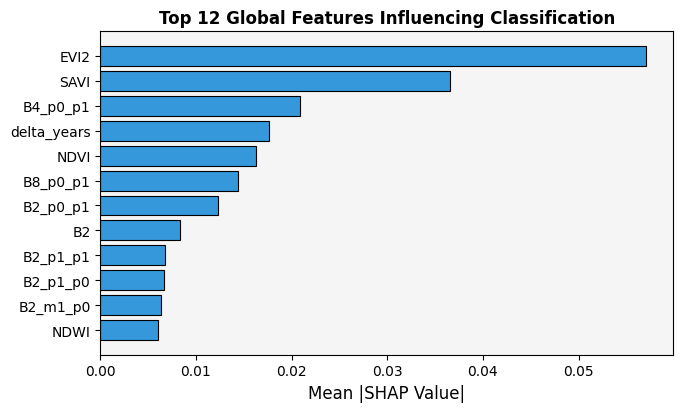

/tmp/ipykernel_190251/3886792679.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


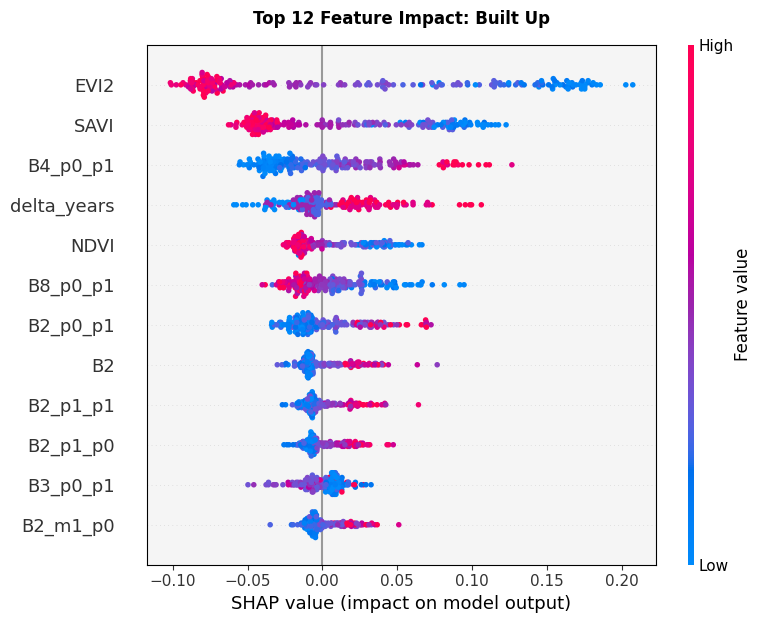

/tmp/ipykernel_190251/3886792679.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


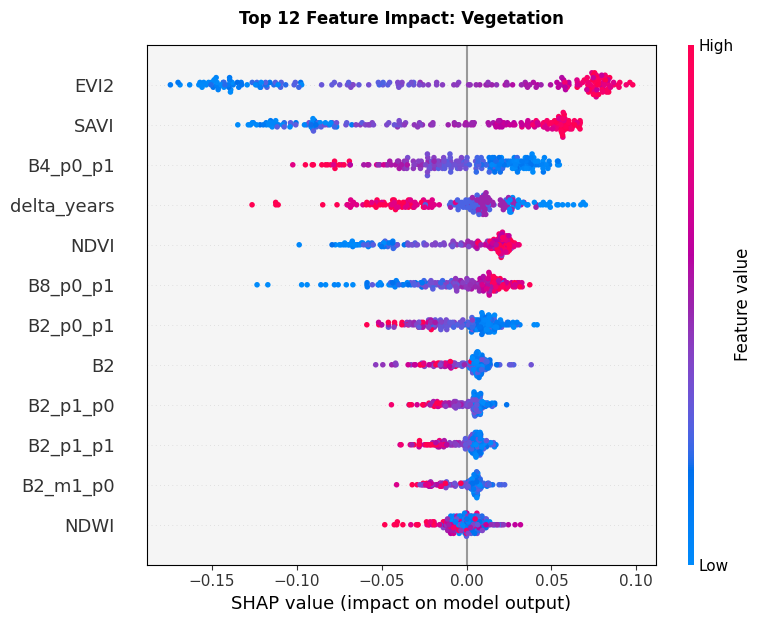

/tmp/ipykernel_190251/3886792679.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


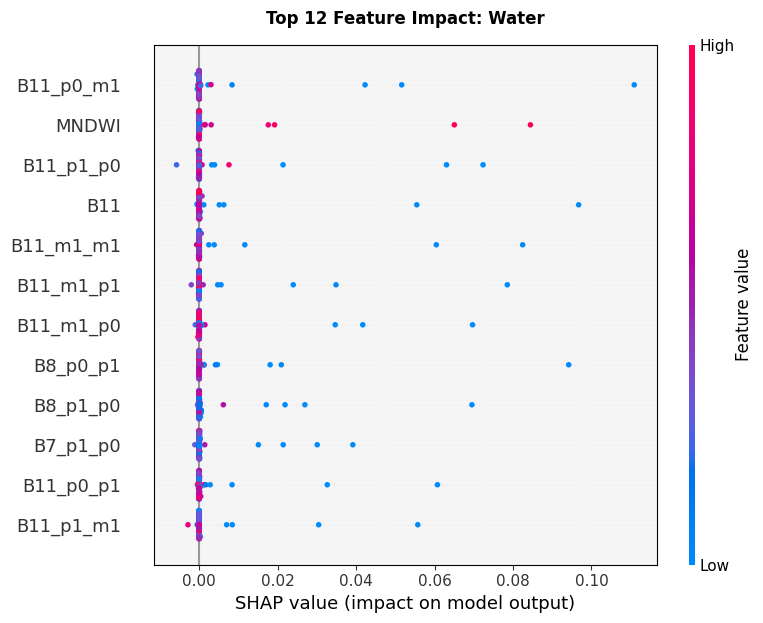

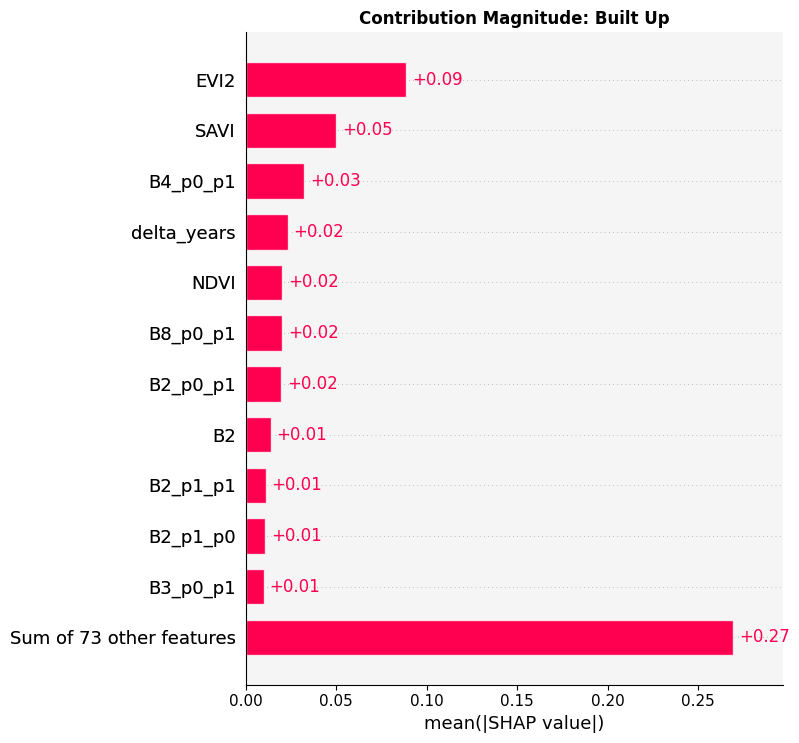

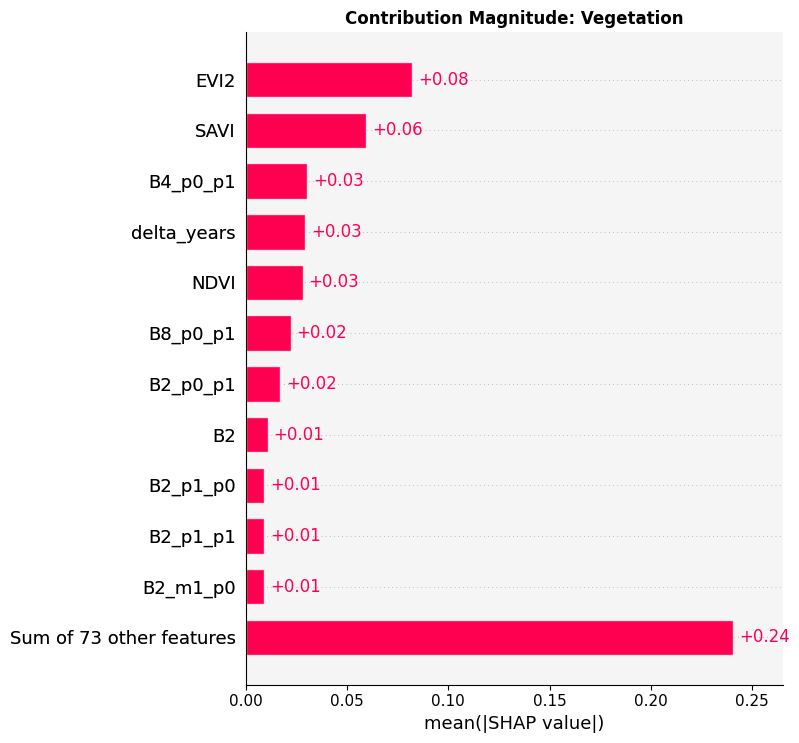

In [15]:
if all_shap_values:
    global_shap_importance = np.mean([np.abs(sv).mean(axis=0) for sv in all_shap_values], axis=0)
    
    importance_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance": global_shap_importance
    }).sort_values(by="importance", ascending=False)

    fig, ax = plt.subplots(figsize=(6.9, 4.2))
    plot_df = importance_df.head(12).iloc[::-1] # Reverse for horizontal bar chart
    
    ax.barh(plot_df["feature"], plot_df["importance"], color="#3498db", edgecolor="black", linewidth=0.8)
    ax.set_xlabel("Mean |SHAP Value|", fontsize=12)
    ax.set_title("Top 12 Global Features Influencing Classification", fontsize=12, fontweight='bold')
    
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color("black")
    
    plt.tight_layout()
    plt.savefig("stack_shap_plots/global_feature_importance.png", dpi=300)
    plt.show()

    for i, target in enumerate(target_names):
        plt.figure(figsize=(7, 5))
        
        shap.summary_plot(
            all_shap_values[i], 
            X_test_small, 
            feature_names=X_test_small.columns.tolist(), 
            plot_type="dot", 
            max_display=12, # Show only top 12
            show=False
        )
        
        curr_ax = plt.gca()
        curr_ax.set_title(f"Top 12 Feature Impact: {target.replace('_', ' ').title()}", fontsize=12, pad=15, fontweight='bold')
        
        for side in ("top", "right", "bottom", "left"):
            curr_ax.spines[side].set_visible(True)
            curr_ax.spines[side].set_color("black")
        
        plt.savefig(f"stack_shap_plots/shap_summary_{target}.png", dpi=300, bbox_inches="tight")
        plt.tight_layout()
        plt.show()

    plt.figure(figsize=(7, 4))
    exp = shap.Explanation(
        values=all_shap_values[0], 
        data=X_test_small.values, 
        feature_names=X_test_small.columns.tolist()
    )
    shap.plots.bar(exp, max_display=12, show=False)

    ax = plt.gca()
    labels = [item.get_text() for item in ax.get_yticklabels()]
    # Replace the long string with a shorter one
    new_labels = [label.replace("Sum of 72 other features", "Sum of\n72 other\nfeatures") for label in labels]
    ax.set_yticklabels(new_labels)

    plt.title(f"Contribution Magnitude: {target_names[0].replace('_', ' ').title()}", fontsize=12, fontweight='bold')
    plt.savefig(f"stack_shap_plots/shap_bar_contribution_{target_names[0]}.png", dpi=300, bbox_inches="tight")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    exp = shap.Explanation(
        values=all_shap_values[1], 
        data=X_test_small.values, 
        feature_names=X_test_small.columns.tolist()
    )
    shap.plots.bar(exp, max_display=12, show=False)

    ax = plt.gca()
    labels = [item.get_text() for item in ax.get_yticklabels()]
    # Replace the long string with a shorter one
    new_labels = [label.replace("Sum of 72 other features", "Sum of\n72 other\nfeatures") for label in labels]
    ax.set_yticklabels(new_labels)

    plt.title(f"Contribution Magnitude: {target_names[1].replace('_', ' ').title()}", fontsize=12, fontweight='bold')
    plt.savefig(f"stack_shap_plots/shap_bar_contribution_{target_names[1]}.png", dpi=300, bbox_inches="tight")
    plt.tight_layout()
    plt.show()

else:
    print("No SHAP values were generated. Check for model/data errors.")